# Notebook 01 — Data Pipeline & EDA

**Section ownership:** Section 2 (Exploratory Data Analysis) is Focus Area A — Royston.
All other sections (configuration, dataset loading and versioning, feature engineering,
train/test split, TF-IDF fitting, and the S3 handoff) are Focus Area C — MLOps data
pipeline, contributed by Ong Hui Lin (Student 2).

The data-quality checks currently in Section 2 were run by Hui Lin as input to the AI
governance assessment (class balance, platform-level scam rates, duplicates); Royston
extends this section with the full EDA and insights.

> **Adapted for team03 (Ong Hui Lin, Student 2 — MLOps & Deployment) from the ITI113 course template notebook `01_eda_and_data_preparation.ipynb`.** The tutor's notebook mixes two things: EDA/insights (individually graded as Focus A — Royston's) and data loading/preparation (the MLOps data pipeline — this project's job). **Section 2 (EDA) is intentionally left as a placeholder for Royston to fill in** rather than written on his behalf. Everything else follows the tutor's structure as closely as the data allows, adapted to text data (TF-IDF) instead of tabular clinical features. Data cleaning and feature engineering are written **inline in this notebook**, the same way the tutor's own notebook is self-contained, rather than imported from `utils/preprocessing.py` — this notebook now runs standalone in SageMaker Studio with no repo clone required. Sections marked **`# ADAPTED`** explain what had to change.
>
> **Trade-off:** `utils/preprocessing.py` (used by Notebook 02 and the Streamlit app) has this same cleaning/feature logic. Keeping this notebook's inline copy and that file in sync is now a manual step — if the cleaning or feature-engineering logic ever changes, update both places, or the app's predictions could drift from what the model was actually trained on.

In [1]:
# After running, restart the kernel before continuing if packages were upgraded.
%pip install -q --upgrade --force-reinstall "sagemaker>=2,<3" boto3 botocore
!pip install -q -U kagglehub rapidfuzz

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlflow 3.14.0 requires pandas<3, but you have pandas 3.0.5 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


## 0. Configuration

Edit the values in this cell. Everything else references these variables.

In [57]:
import sagemaker, boto3
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

session = sagemaker.Session()
role    = sagemaker.get_execution_role()
region  = boto3.Session().region_name

TEAM_ID = "team03"
STUDENT_ID = "s301"

BUCKET = "nyp-26s1-iti113"
PROJECT_NAME = "crypto-scam-detector"
PREFIX = f"iti113/{TEAM_ID}/data/{PROJECT_NAME}"  # matches the PREFIX pattern used in Notebook 02

RANDOM_STATE = 42   # matches utils/preprocessing.py's default, kept identical so results match your Mac runs
TEST_SIZE    = 0.20 # matches utils/preprocessing.py's default

print(f"Bucket     : {BUCKET}")
print(f"Prefix     : {PREFIX}")
print(f"Region     : {region}")
print(f"Role       : {role.split('/')[-1]}")
print(f"Team ID    : {TEAM_ID}")
print(f"Student ID : {STUDENT_ID}")

Bucket     : nyp-26s1-iti113
Prefix     : iti113/team03/data/crypto-scam-detector
Region     : ap-southeast-1
Role       : SageMakerExecutionRole-ITI113-Team03
Team ID    : team03
Student ID : s301


In [ ]:
# Imports and AWS clients used throughout this notebook.
# Kept in one place so the notebook runs top-to-bottom from a fresh kernel
# (Kernel -> Restart & Run All) without relying on state left by earlier sessions.
import os
import io
import json
import hashlib

import numpy as np
import pandas as pd
import kagglehub

s3 = boto3.client("s3")

print("Imports ready. S3 client region:", s3.meta.region_name)

## 1. Load Dataset

**ADAPTED:** the tutor's version downloads the UCI Heart Disease dataset from a public URL, then uploads it to S3 for version control. This project's raw dataset doesn't have an equivalent no-auth public URL, so `kagglehub` downloads it directly from Kaggle instead -- this avoids depending on a local repo checkout of `data/crypto_scam_dataset.csv`, which matters in SageMaker Studio (no repo clone here). This cell checks S3 first and loads from there if the raw file already exists (`{PREFIX}/raw/crypto_scam_dataset.csv`); only on the very first run anywhere does it fall back to `kagglehub` and upload the result -- so every run after that, on any machine, reads from S3 instead of re-fetching from Kaggle each time.

| Column | Description |
|--------|-------------|
| id | Unique message identifier |
| platform | Source platform (Telegram, X/Twitter, SMS, Email, Discord, Reddit) |
| text | Message content |
| label | `scam` or `legit` |

In [2]:
import hashlib
import json

POINTER_KEY = f'{PREFIX}/raw/_latest.json'  # small metadata file tracking current version + hash

def get_pointer():
    try:
        obj = s3.get_object(Bucket=BUCKET, Key=POINTER_KEY)
        return json.loads(obj['Body'].read())
    except s3.exceptions.NoSuchKey:
        return {"version": 0, "sha256": None, "s3_key": None}

def put_pointer(pointer):
    s3.put_object(Bucket=BUCKET, Key=POINTER_KEY, Body=json.dumps(pointer, indent=2))

# Always pull fresh from Kaggle -- bypass kagglehub's own cache
dataset_path = kagglehub.dataset_download("theeyanyan/crypto-scam-dataset", force_download=True)
csv_file = os.path.join(dataset_path, "crypto_scam_dataset.csv")

with open(csv_file, "rb") as f:
    raw_bytes = f.read()
new_hash = hashlib.sha256(raw_bytes).hexdigest()

pointer = get_pointer()

if new_hash == pointer["sha256"]:
    print(f'No change detected (sha256={new_hash[:12]}...). Using existing version v{pointer["version"]}: {pointer["s3_key"]}')
    RAW_S3_KEY = pointer["s3_key"]
else:
    new_version = pointer["version"] + 1
    RAW_S3_KEY = f'{PREFIX}/raw/crypto_scam_dataset_v{new_version}.csv'
    s3.put_object(Bucket=BUCKET, Key=RAW_S3_KEY, Body=raw_bytes)
    put_pointer({"version": new_version, "sha256": new_hash, "s3_key": RAW_S3_KEY})
    print(f'New version detected -- uploaded v{new_version}: s3://{BUCKET}/{RAW_S3_KEY}')

RAW_S3_URI = f's3://{BUCKET}/{RAW_S3_KEY}'
df_raw = pd.read_csv(io.BytesIO(raw_bytes))
print(f'Shape : {df_raw.shape}')
print(f'Label : {df_raw["label"].value_counts().to_dict()}')
df_raw.head()

NameError: name 'PREFIX' is not defined

## 2. Exploratory Data Analysis

**Focus Area A — Royston.** The cells below cover the data-quality and bias checks needed
for the AI governance assessment: missing values, duplicates, class balance, platform
distribution and per-platform scam rates, and common scam-language patterns. Royston
extends this section with the fuller EDA and written insights required by the rubric.

In [59]:
# Missing values
print("Missing values per column:")
print(df_raw.isnull().sum())
print(f"\nTotal missing: {df_raw.isnull().sum().sum()}")

# Duplicate check (important before train/test split)
n_dupes = df_raw.duplicated(subset="text").sum()
print(f"\nDuplicate messages (exact text match): {n_dupes} ({n_dupes/len(df_raw):.2%})")

Missing values per column:
id          0
platform    0
text        0
label       0
dtype: int64

Total missing: 0

Duplicate messages (exact text match): 0 (0.00%)


Class balance:
label
scam     5500
legit    4500
Name: count, dtype: int64
label
scam     55.0
legit    45.0
Name: proportion, dtype: float64


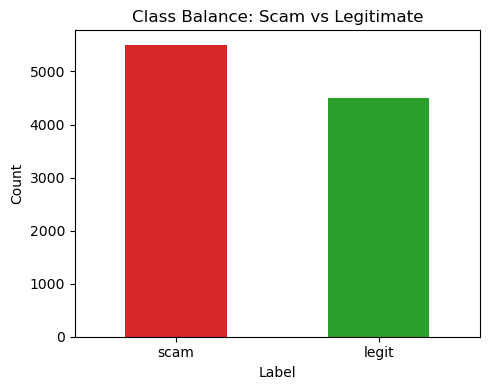

In [60]:
import matplotlib.pyplot as plt

label_counts = df_raw["label"].value_counts()
label_pct = df_raw["label"].value_counts(normalize=True) * 100

print("Class balance:")
print(label_counts)
print(label_pct.round(2))

fig, ax = plt.subplots(figsize=(5, 4))
label_counts.plot(kind="bar", ax=ax, color=["#d62728", "#2ca02c"])
ax.set_title("Class Balance: Scam vs Legitimate")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Messages per platform:
platform
Twitter/X    1740
SMS          1726
Email        1691
Discord      1665
Telegram     1605
Reddit       1573
Name: count, dtype: int64



Scam rate by platform:
platform
Email        0.569
Twitter/X    0.561
Telegram     0.559
Reddit       0.555
Discord      0.529
SMS          0.527
Name: label, dtype: float64


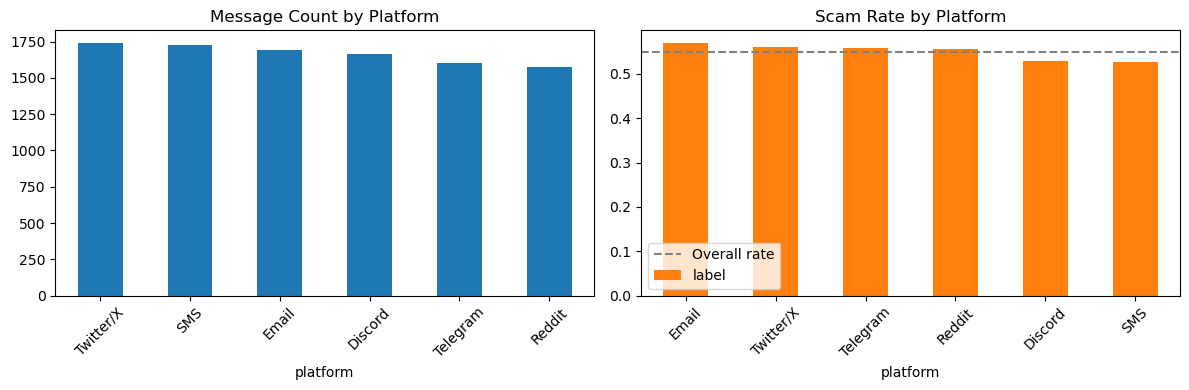

In [61]:
# Overall platform counts
platform_counts = df_raw["platform"].value_counts()
print("Messages per platform:")
print(platform_counts)

# Scam rate WITHIN each platform -- checks for platform-driven bias
platform_scam_rate = df_raw.groupby("platform")["label"].apply(
    lambda x: (x == "scam").mean()
).sort_values(ascending=False)

print("\nScam rate by platform:")
print(platform_scam_rate.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
platform_counts.plot(kind="bar", ax=axes[0], color="#1f77b4")
axes[0].set_title("Message Count by Platform")
axes[0].tick_params(axis="x", rotation=45)

platform_scam_rate.plot(kind="bar", ax=axes[1], color="#ff7f0e")
axes[1].set_title("Scam Rate by Platform")
axes[1].axhline(y=(df_raw["label"]=="scam").mean(), color="gray", linestyle="--", label="Overall rate")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()
plt.tight_layout()
plt.show()

In [62]:
from sklearn.feature_extraction.text import CountVectorizer

def top_ngrams(texts, n=20, ngram_range=(1, 1)):
    vec = CountVectorizer(stop_words="english", ngram_range=ngram_range, max_features=2000)
    matrix = vec.fit_transform(texts)
    freqs = matrix.sum(axis=0).A1
    vocab = vec.get_feature_names_out()
    return pd.Series(freqs, index=vocab).sort_values(ascending=False).head(n)

scam_text = df_raw[df_raw["label"] == "scam"]["text"]
legit_text = df_raw[df_raw["label"] == "legit"]["text"]

print("Top 20 words in SCAM messages:")
print(top_ngrams(scam_text, n=20, ngram_range=(1, 1)))

print("\nTop 20 words in LEGIT messages:")
print(top_ngrams(legit_text, n=20, ngram_range=(1, 1)))

print("\nTop 15 bigrams in SCAM messages:")
print(top_ngrams(scam_text, n=15, ngram_range=(2, 2)))

Top 20 words in SCAM messages:
wallet     3099
eth        1982
send       1587
small      1364
com        1339
weth       1239
hours      1213
usdt       1192
usdc       1184
funds      1181
month      1116
ve         1072
minutes     995
spots       924
need        885
verify      830
confirm     816
just        796
support     784
io          776
dtype: int64

Top 20 words in LEGIT messages:


wallet          1432
new             1240
gas             1161
just             990
reading          960
time             828
eth              795
contract         770
support          728
transactions     689
like             638
com              634
going            634
way              631
team             626
check            575
want             529
transaction      528
week             520
good             503
dtype: int64

Top 15 bigrams in SCAM messages:
filling fast        557
permanent loss      529
just need           441
month start         429
funds tied          366
spots filling       310
major exchanges     307
spots left          303
verify wallet       278
offer expires       276
don miss            254
price 100x          251
100x potential      247
presale wallet      242
allocations left    242
dtype: int64


In [63]:
print("Data Quality & Bias Summary\n")

print(f"1. Missing values: {df_raw.isnull().sum().sum()} total")
print(f"2. Duplicate messages: {n_dupes} ({n_dupes/len(df_raw):.2%})")
print(f"3. Class balance: {label_pct.round(1).to_dict()}")
print(f"4. Platform coverage: {len(platform_counts)} platforms, "
      f"ranging from {platform_counts.min()} to {platform_counts.max()} messages each")
print(f"5. Scam rate varies by platform: "
      f"{platform_scam_rate.min():.2f} to {platform_scam_rate.max():.2f} ")

Data Quality & Bias Summary

1. Missing values: 0 total
2. Duplicate messages: 0 (0.00%)
3. Class balance: {'scam': 55.0, 'legit': 45.0}
4. Platform coverage: 6 platforms, ranging from 1573 to 1740 messages each
5. Scam rate varies by platform: 0.53 to 0.57 


## 3. Feature Engineering & Preprocessing

**Focus Area C — MLOps data pipeline (Hui Lin).**

Written inline rather than imported from `utils/`, so the notebook runs standalone in
SageMaker Studio without cloning the repo. Four steps:

1. **Text cleaning** — URLs are replaced with a `<url>` token before lowercasing, so the
   presence of a link is kept as signal while specific domains are discarded.
2. **Engineered indicator features** — 18 features (13 count/continuous, 5 binary) covering
   urgency, guaranteed-return, payment, off-platform and credential-harvesting language,
   plus wallet/URL/email/phone patterns and structural characteristics. These run on the
   **raw** text, not the cleaned text, because capitalisation ratio and URL presence would
   otherwise be destroyed by cleaning.
3. **Stratified train/test split** — 80/20 with a fixed random seed, preserving the
   55/45 class ratio in both splits.
4. **TF-IDF fitting** — fitted on the **training split only**. This is the project's main
   leakage control: the vocabulary and IDF weights are learned from training data alone
   and then applied unchanged to the test set.

No feature scaling is applied, consistent with the rest of the project.

In [64]:
# Step 1: clean text (mirrors utils/preprocessing.py's clean_text())
import re

URL_PATTERN = re.compile(r"https?://[^\s]+|www\.[^\s]+")

def clean_text(text: str) -> str:
    """Normalise raw message text before TF-IDF vectorisation."""
    if not isinstance(text, str):
        return ""
    text = text.strip()
    text = URL_PATTERN.sub(" <url> ", text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df = df_raw.copy()
df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text"]].head()

,text,clean_text
0,Following up on your recovery request for wall...,following up on your recovery request for wall...
1,Does anyone have a good resource for understan...,does anyone have a good resource for understan...
2,The MetaSwap team posted a security disclosure...,the metaswap team posted a security disclosure...
3,Been dollar-cost averaging into ETH for about ...,been dollar-cost averaging into eth for about ...
4,Your account requires immediate verification d...,your account requires immediate verification d...


In [65]:
# Step 2: engineered indicator features (mirrors utils/indicators.py + utils/preprocessing.py)
# Keyword lists come straight from the project proposal's indicator design.
# General urgency/pressure tactics — common across phishing, romance scams,
# and investment fraud, not specific to crypto or this dataset.
URGENT_KEYWORDS = [
    "urgent", "immediately", "hurry", "act now", "act fast", "limited time",
    "limited slots", "limited spots", "today only", "last chance",
    "final notice", "final warning", "don't miss", "don't wait",
    "expires", "expiring", "closing soon", "ending soon", "before it's too late",
    "respond now", "reply now", "confirm now", "verify now", "claim now",
    "while supplies last", "only a few left", "act before", "time-sensitive",
    "this offer", "exclusive offer", "one time offer",
]

# Unrealistic profit/return promises — a core red flag across all investment
# fraud (Ponzi schemes, pump-and-dumps, forex scams), not crypto-specific.
GUARANTEED_RETURN_KEYWORDS = [
    "guaranteed", "guarantee", "risk-free", "risk free", "no risk",
    "zero risk", "sure profit", "sure win", "can't lose", "cannot lose",
    "double your money", "triple your money", "multiply your", "10x", "100x",
    "passive income", "easy money", "get rich", "financial freedom",
    "life-changing", "once in a lifetime", "secret method", "proven strategy",
    "insider information", "insider tip", "exclusive access", "vip access",
]

# Payment/transfer requests — general fraud indicator (also seen in romance
# scams, tech-support scams, fake job offers), phrased broadly.
PAYMENT_KEYWORDS = [
    "deposit", "transfer", "send funds", "send payment", "send money",
    "top up", "top-up", "processing fee", "activation fee", "unlock fee",
    "advance fee", "small fee", "gas fee", "network fee", "wallet",
    "crypto", "bitcoin", "ethereum", "usdt", "stablecoin",
]

# Off-platform / private-channel redirection — a general grooming and scam
# pattern (moving victims away from a platform's moderation and paper trail).
OFF_PLATFORM_KEYWORDS = [
    "telegram", "whatsapp", "discord", "signal", "wechat", "line app",
    "private chat", "private message", "dm me", "direct message",
    "text me", "call me", "contact me directly", "reach out privately",
    "add me on",
]

# Credential/secret-harvesting requests — a general phishing red flag
# (applies to bank phishing, email account takeover, and crypto wallets alike).
CREDENTIAL_KEYWORDS = [
    "seed phrase", "private key", "recovery phrase", "recovery key",
    "wallet password", "login credentials", "verification code", "otp",
    "security code", "pin number", "social security", "confirm your identity",
    "confirm your account", "reset your password", "unusual activity",
    "suspended account", "locked account", "verify your account",
]

WALLET_PATTERN = re.compile(r"\b(?:0x[a-fA-F0-9]{40}|[13][a-km-zA-HJ-NP-Z1-9]{25,34})\b")
EMAIL_PATTERN = re.compile(r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}")
PHONE_PATTERN = re.compile(r"(?:\+?\d[\d\s-]{7,}\d)")
COUNTDOWN_PATTERN = re.compile(r"\b\d+\s*(?:hour|hours|hr|hrs|minute|minutes|min|mins|day|days)\b", re.IGNORECASE)

def find_keyword_matches(message: str, keywords: list) -> list:
    """Exact substring match. Kept for reference/comparison against the fuzzy version below."""
    message_lower = message.lower()
    return [k for k in keywords if k.lower() in message_lower]

# NEW: fuzzy matcher, tolerates typos generically (no dataset-specific fixes)
from rapidfuzz import fuzz

def find_keyword_matches_fuzzy(message: str, keywords: list, threshold: int = 85) -> list:
    """Typo-tolerant match: token-level ratio for single words, partial_ratio for phrases."""
    message_lower = message.lower()
    tokens = message_lower.split()
    matches = []
    for kw in keywords:
        kw_lower = kw.lower()
        if " " in kw_lower:
            if fuzz.partial_ratio(kw_lower, message_lower) >= threshold:
                matches.append(kw)
        else:
            if any(fuzz.ratio(kw_lower, tok) >= threshold for tok in tokens):
                matches.append(kw)
    return matches

def extract_engineered_features(text: str) -> dict:
    if not isinstance(text, str):
        text = ""

    urgency_keyword_hits = len(find_keyword_matches_fuzzy(text, URGENT_KEYWORDS))
    guaranteed_return_hits = len(find_keyword_matches_fuzzy(text, GUARANTEED_RETURN_KEYWORDS))
    countdown_hits = len(COUNTDOWN_PATTERN.findall(text))
    exclamation_count = text.count("!")
    urgency_score = urgency_keyword_hits + countdown_hits + min(exclamation_count, 3)

    wallet_matches = WALLET_PATTERN.findall(text)
    url_matches = URL_PATTERN.findall(text)
    email_matches = EMAIL_PATTERN.findall(text)
    phone_matches = PHONE_PATTERN.findall(text)
    payment_hits = len(find_keyword_matches_fuzzy(text, PAYMENT_KEYWORDS))
    off_platform_hits = len(find_keyword_matches_fuzzy(text, OFF_PLATFORM_KEYWORDS))
    credential_hits = len(find_keyword_matches_fuzzy(text, CREDENTIAL_KEYWORDS))

    letters = [c for c in text if c.isalpha()]
    capital_ratio = sum(1 for c in letters if c.isupper()) / len(letters) if letters else 0.0
    digit_count = sum(1 for c in text if c.isdigit())

    return {
        "urgency_keyword_count": urgency_keyword_hits,
        "guaranteed_return_keyword_count": guaranteed_return_hits,
        "countdown_phrase_count": countdown_hits,
        "exclamation_count": exclamation_count,
        "urgency_score": urgency_score,
        "has_wallet_address": int(bool(wallet_matches)),
        "wallet_address_count": len(wallet_matches),
        "has_url": int(bool(url_matches)),
        "url_count": len(url_matches),
        "has_email": int(bool(email_matches)),
        "has_phone_number": int(bool(phone_matches)),
        "payment_keyword_count": payment_hits,
        "off_platform_keyword_count": off_platform_hits,
        "credential_keyword_count": credential_hits,
        "message_length": len(text),
        "capital_letter_ratio": round(capital_ratio, 4),
        "has_numeric_content": int(digit_count > 0),
        "digit_count": digit_count,
    }

engineered = pd.DataFrame([extract_engineered_features(t) for t in df["text"]], index=df.index)
ENGINEERED_COLS = list(engineered.columns)
df = pd.concat([df, engineered], axis=1)
df[ENGINEERED_COLS].head()

,urgency_keyword_count,guaranteed_return_keyword_count,countdown_phrase_count,exclamation_count,urgency_score,has_wallet_address,wallet_address_count,has_url,url_count,has_email,has_phone_number,payment_keyword_count,off_platform_keyword_count,credential_keyword_count,message_length,capital_letter_ratio,has_numeric_content,digit_count
0,1,0,1,0,2,1,2,0,0,0,1,1,0,0,292,0.0370,1,61
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,212,0.0412,1,4
2,0,0,0,0,0,0,0,0,0,0,0,1,0,0,176,0.0286,0,0
3,0,0,0,0,0,0,0,0,0,0,1,0,0,0,286,0.0327,1,12
4,1,0,1,0,2,0,0,0,0,1,0,1,0,1,220,0.0718,1,3


In [66]:
# Step 3: train/test split (stratified on label)
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df["label"],
)

print(f'Train: {train_df.shape[0]} rows  |  Test: {test_df.shape[0]} rows')
print(f'Train label balance: {(train_df["label"]=="scam").mean():.3f}  '
      f'(full dataset: {(df_raw["label"]=="scam").mean():.3f})')
print(f'Test  label balance: {(test_df["label"]=="scam").mean():.3f}  (stratification confirmed)')

Train: 8000 rows  |  Test: 2000 rows
Train label balance: 0.550  (full dataset: 0.550)
Test  label balance: 0.550  (stratification confirmed)


In [68]:
# Step 4: fit TF-IDF vectorizer -- IMPORTANT: fit on TRAIN text only, never on test
from sklearn.feature_extraction.text import TfidfVectorizer

# Version A: default (no stopword removal) -- current baseline
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
vectorizer.fit(train_df["clean_text"])
print(f'[No stopword removal] TF-IDF vocabulary size: {len(vectorizer.get_feature_names_out())}')

# Version B: with English stopwords removed -- comparison
vectorizer_no_stop = TfidfVectorizer(
    max_features=5000, ngram_range=(1, 2), min_df=2, stop_words="english"
)
vectorizer_no_stop.fit(train_df["clean_text"])
print(f'[With stopword removal] TF-IDF vocabulary size: {len(vectorizer_no_stop.get_feature_names_out())}')

# Quick sanity check: does removing stopwords drop any scam-relevant phrases?
vocab_default = set(vectorizer.get_feature_names_out())
vocab_no_stop = set(vectorizer_no_stop.get_feature_names_out())
dropped = vocab_default - vocab_no_stop
print(f'\nTerms dropped by stopword removal: {len(dropped)}')
print(f'Sample dropped terms: {list(dropped)[:20]}')

# Specifically check if any dropped terms overlap with your urgency/scam keyword lists
scam_relevant_keywords = set(
    kw.lower() for kw in URGENT_KEYWORDS + GUARANTEED_RETURN_KEYWORDS + PAYMENT_KEYWORDS
)
overlap = {term for term in dropped if any(term in kw or kw in term for kw in scam_relevant_keywords)}
print(f'Dropped terms overlapping scam keyword lists: {overlap}')

[No stopword removal] TF-IDF vocabulary size: 5000


[With stopword removal] TF-IDF vocabulary size: 5000

Terms dropped by stopword removal: 2074
Sample dropped terms: ['wek we', 've been', 'reading up', 'david here', 'for layerbridge', 'two minor', 'now caught', 'is etherscan', 'automatically only', 'for web3', 'every payday', 'up our', 'now do', 'else comes', 'years and', 'conversation my', 'again', 'it affects', 'should try', 'fom the']
Dropped terms overlapping scam keyword lists: {'wallet to', 'there', 'expires in', 'if', 'the', 'do', 'be', 'all', 'usdt for', 'your wallet', 'wallet nothing', 'urgent your', 'at', 'ethclaim now', 'is', 'two', 'the crypto', 'of', 'this offer', 'your', '3xclaim now', 'of usdt', 'usdt over', 'immediately or', 'anything urgent', 'this', 'wallets will', 'usdt only', 'wallet been', 'now', 'my usdt', 'an', 'from wallet', 'wallet would', 'me', 'for usdt', 'on', 'as', 'last', 'urgent we', 'for wallet', 'co', 'you', 'hurry this', 'some usdt', 'wallets anyone', 'usdt from', 'wallets our', 'wallets the', 'before

## 4. Engineered Features EDA

In [69]:
import seaborn as sns
from scipy import stats

# Distributions of engineered features
BINARY_FEATURES = [
    "has_wallet_address", "has_url", "has_email",
    "has_phone_number", "has_numeric_content",
]

CONTINUOUS_FEATURES = [
    "urgency_keyword_count", "guaranteed_return_keyword_count", "countdown_phrase_count",
    "exclamation_count", "urgency_score", "wallet_address_count", "url_count",
    "payment_keyword_count", "off_platform_keyword_count", "credential_keyword_count",
    "message_length", "capital_letter_ratio", "digit_count",
]

ALL_FEATURES = BINARY_FEATURES + CONTINUOUS_FEATURES

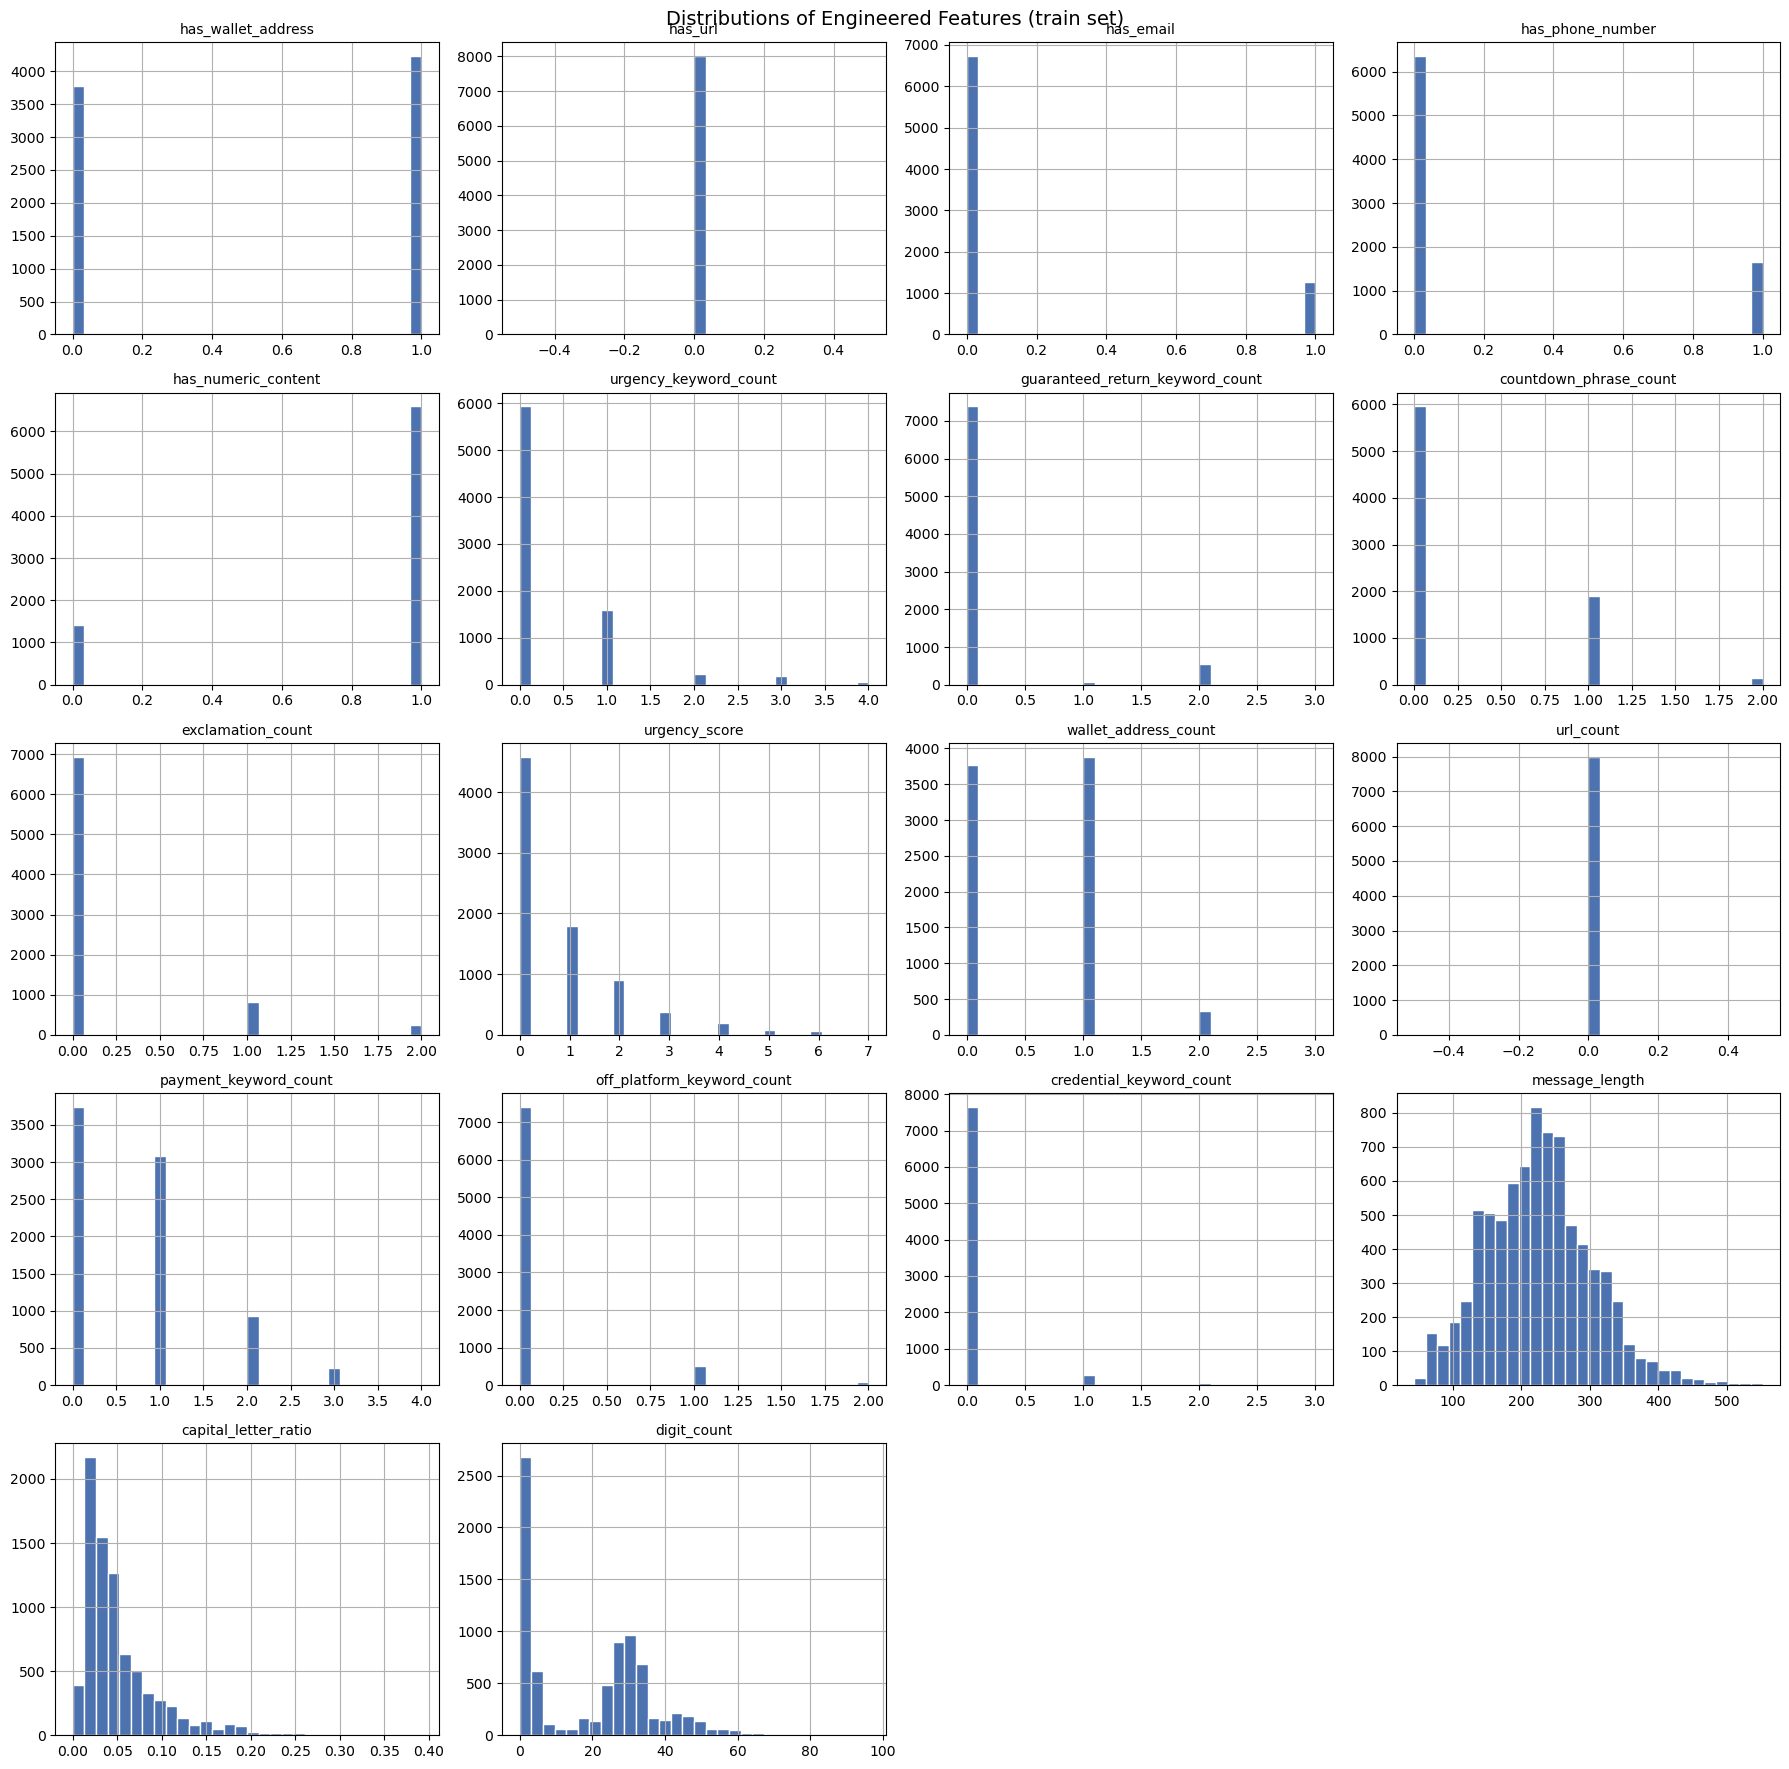

In [70]:
# Boxplots by label
fig, axes = plt.subplots(5, 4, figsize=(18, 18))
axes = axes.flatten()

for ax, feat in zip(axes, ALL_FEATURES):
    train_df[feat].hist(bins=30, ax=ax, color="#4c72b0", edgecolor="white")
    ax.set_title(feat, fontsize=10)

for ax in axes[len(ALL_FEATURES):]:
    ax.axis("off")

plt.suptitle("Distributions of Engineered Features (train set)", fontsize=14)
plt.tight_layout()
plt.show()

In [71]:
results = []

scam_mask = train_df["label"] == "scam"
legit_mask = train_df["label"] == "legit"

# Binary features -> chi-square test of independence
for feat in BINARY_FEATURES:
    contingency = pd.crosstab(train_df[feat], train_df["label"])
    chi2, p, dof, expected = stats.chi2_contingency(contingency)
    results.append({"feature": feat, "test": "chi-square", "statistic": chi2, "p_value": p})

# Continuous/count features -> Mann-Whitney U test (robust to skew, no normality assumption)
for feat in CONTINUOUS_FEATURES:
    scam_vals = train_df.loc[scam_mask, feat]
    legit_vals = train_df.loc[legit_mask, feat]
    u_stat, p = stats.mannwhitneyu(scam_vals, legit_vals, alternative="two-sided")

    # Effect size: rank-biserial correlation (-1 to 1; |r| > 0.3 moderate, > 0.5 large)
    n1, n2 = len(scam_vals), len(legit_vals)
    rank_biserial = 1 - (2 * u_stat) / (n1 * n2)

    results.append({
        "feature": feat, "test": "mann-whitney-u",
        "statistic": u_stat, "p_value": p, "effect_size": round(rank_biserial, 3),
    })

results_df = pd.DataFrame(results)

# Bonferroni correction, since 18 features are tested at once
alpha = 0.05
results_df["bonferroni_alpha"] = alpha / len(results_df)
results_df["significant_after_correction"] = results_df["p_value"] < results_df["bonferroni_alpha"]

results_df = results_df.sort_values("p_value")
print(results_df.to_string(index=False))

                        feature           test    statistic       p_value  effect_size  bonferroni_alpha  significant_after_correction
             has_wallet_address     chi-square 2.515686e+03  0.000000e+00          NaN          0.002778                          True
            has_numeric_content     chi-square 2.062489e+03  0.000000e+00          NaN          0.002778                          True
           wallet_address_count mann-whitney-u 1.239706e+07  0.000000e+00       -0.565          0.002778                          True
                  urgency_score mann-whitney-u 1.234940e+07  0.000000e+00       -0.559          0.002778                          True
                    digit_count mann-whitney-u 1.402645e+07  0.000000e+00       -0.771          0.002778                          True
           capital_letter_ratio mann-whitney-u 1.283726e+07  0.000000e+00       -0.621          0.002778                          True
          urgency_keyword_count mann-whitney-u 1.061833

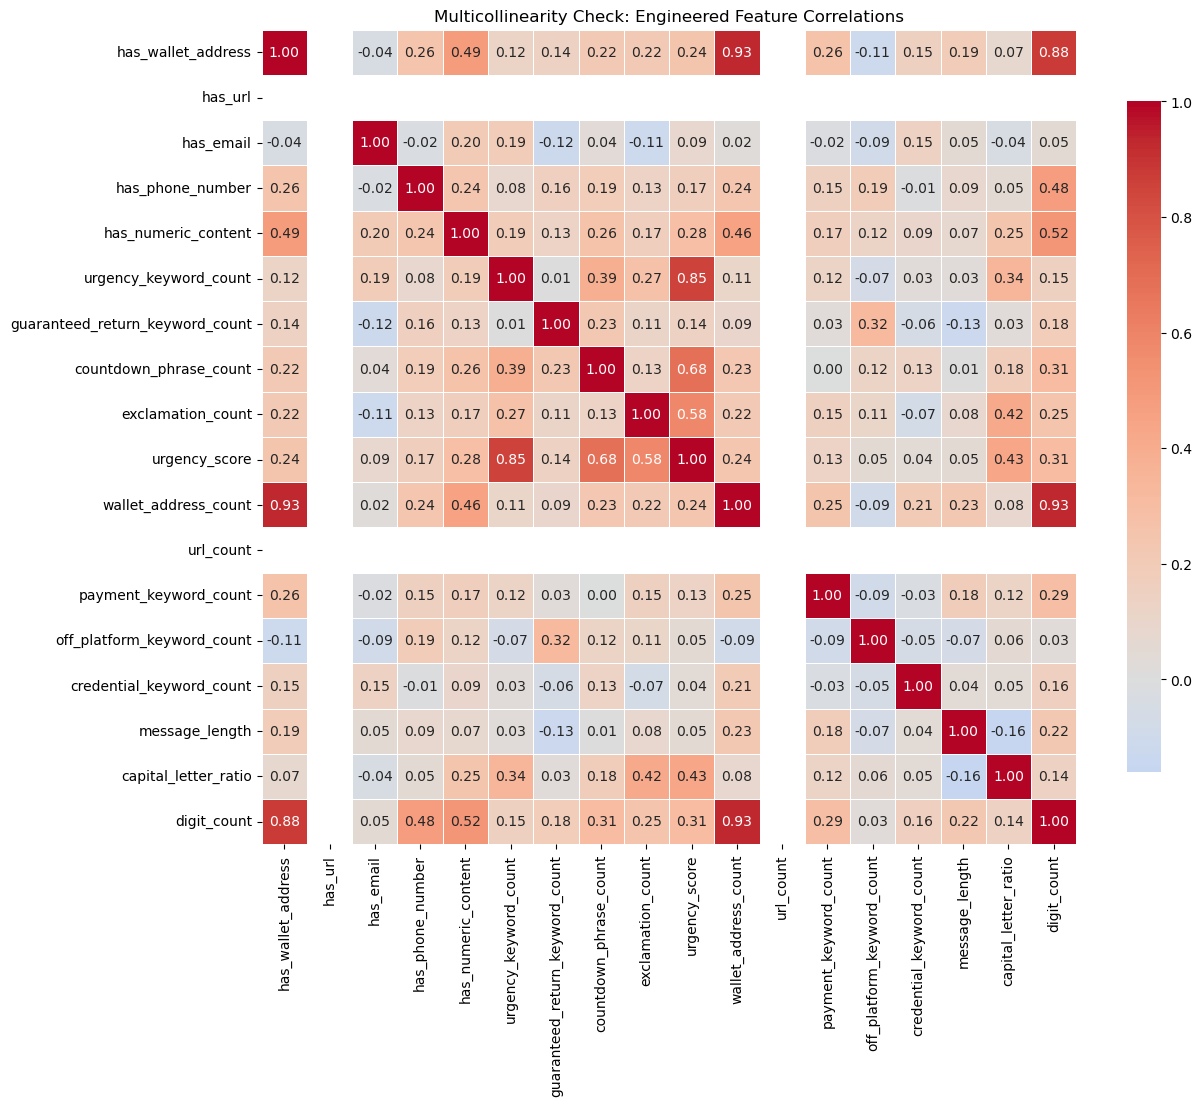

In [72]:
# Correlation heatmap (multicollinearity check)
feature_corr = train_df[ALL_FEATURES].corr()

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    feature_corr, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, square=True, linewidths=0.5,
    cbar_kws={"shrink": 0.8}, ax=ax,
)
ax.set_title("Multicollinearity Check: Engineered Feature Correlations")
plt.tight_layout()
plt.show()

## 5. Save Processed Data to S3

**Focus Area C — MLOps data pipeline (Hui Lin).**

Three artifacts are written to `processed/` and consumed by every downstream notebook:
`train.csv`, `test.csv`, and the fitted `tfidf_vectorizer.joblib`.

The fitted vectoriser is saved rather than rebuilt so that training and serving stay
consistent — the endpoint must transform incoming text using the exact vocabulary and IDF
weights learned during training, not a freshly fitted one.

**Known limitation:** these processed artifacts are written to fixed paths and are
overwritten on each run. Unlike the raw dataset, which is versioned by SHA256, processed
outputs are not versioned, so a model cannot currently be traced to a specific processed
dataset version. Per-run versioning of processed outputs is planned work.

In [73]:
# ADAPTED: the tutor's version saves four numeric CSVs (train/test features and labels
# split apart), which fits tabular data. This project's processed output is train_df /
# test_df (text + engineered features + label together, matching data/processed/*.csv
# already produced locally) plus the fitted TF-IDF vectorizer -- so three artifacts are
# uploaded instead. If Notebook 02/03 are later switched to load from S3 instead of
# re-running the pipeline locally, they should read these three, not the tutor's four.

import joblib
import tempfile

def save_csv_to_s3(df, bucket, key):
    buf = io.StringIO()
    df.to_csv(buf, index=False)
    s3.put_object(Bucket=bucket, Key=key, Body=buf.getvalue())
    return f's3://{bucket}/{key}'

def save_joblib_to_s3(obj, bucket, key):
    with tempfile.NamedTemporaryFile(suffix='.joblib') as tmp:
        joblib.dump(obj, tmp.name)
        s3.upload_file(tmp.name, bucket, key)
    return f's3://{bucket}/{key}'

p = f'{PREFIX}/processed'
paths = {
    'train'            : save_csv_to_s3(train_df, BUCKET, f'{p}/train.csv'),
    'test'             : save_csv_to_s3(test_df, BUCKET, f'{p}/test.csv'),
    'tfidf_vectorizer' : save_joblib_to_s3(vectorizer, BUCKET, f'{p}/tfidf_vectorizer.joblib'),
}
for name, uri in paths.items():
    print(f'{name:<20}: {uri}')

PROCESSED_PREFIX = f's3://{BUCKET}/{p}'
print(f'\nProcessed prefix: {PROCESSED_PREFIX}')
print('Next: open Notebook 02 to run baseline experiments with MLflow.')

train               : s3://nyp-26s1-iti113/iti113/team03/data/crypto-scam-detector/processed/train.csv
test                : s3://nyp-26s1-iti113/iti113/team03/data/crypto-scam-detector/processed/test.csv
tfidf_vectorizer    : s3://nyp-26s1-iti113/iti113/team03/data/crypto-scam-detector/processed/tfidf_vectorizer.joblib

Processed prefix: s3://nyp-26s1-iti113/iti113/team03/data/crypto-scam-detector/processed
Next: open Notebook 02 to run baseline experiments with MLflow.


---
## Handoff to Notebook 02

Produced by this notebook and consumed downstream:

- Raw dataset versioned in S3 under `raw/`, with `_latest.json` recording the current
  version and its SHA256 hash
- `processed/train.csv` and `processed/test.csv` — stratified 80/20 split including the
  engineered features and label
- `processed/tfidf_vectorizer.joblib` — fitted on the training split only

Notebook 02 loads these three artifacts directly rather than re-running this pipeline, so
all baseline and tuning runs share one feature representation.